In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\LENOVO\Desktop\customer-churn-prediction\data\customer_churn_1M.csv")

In [3]:
df.head()

,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,...,1,1,9.0,0.0,0,0,109.63,16,NaN,0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


In [4]:
df.shape

(1000000, 32)

In [5]:
df.dtypes

customer_id                        str
signup_date                        str
age                              int64
gender                             str
annual_income                  float64
education                          str
marital_status                     str
dependents                       int64
tenure                           int64
contract                           str
payment_method                     str
paperless_billing                  str
senior_citizen                   int64
monthlycharges                 float64
totalcharges                   float64
num_services                     int64
has_phone_service                int64
has_internet_service             int64
has_online_security              int64
has_online_backup                int64
has_device_protection            int64
has_tech_support                 int64
has_streaming_tv                 int64
has_streaming_movies             int64
customer_satisfaction          float64
num_complaints           

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   customer_id                  1000000 non-null  str    
 1   signup_date                  1000000 non-null  str    
 2   age                          1000000 non-null  int64  
 3   gender                       1000000 non-null  str    
 4   annual_income                970041 non-null   float64
 5   education                    1000000 non-null  str    
 6   marital_status               1000000 non-null  str    
 7   dependents                   1000000 non-null  int64  
 8   tenure                       1000000 non-null  int64  
 9   contract                     1000000 non-null  str    
 10  payment_method               1000000 non-null  str    
 11  paperless_billing            1000000 non-null  str    
 12  senior_citizen               1000000 non-null  int64  

In [7]:
df.columns

Index(['customer_id', 'signup_date', 'age', 'gender', 'annual_income',
       'education', 'marital_status', 'dependents', 'tenure', 'contract',
       'payment_method', 'paperless_billing', 'senior_citizen',
       'monthlycharges', 'totalcharges', 'num_services', 'has_phone_service',
       'has_internet_service', 'has_online_security', 'has_online_backup',
       'has_device_protection', 'has_tech_support', 'has_streaming_tv',
       'has_streaming_movies', 'customer_satisfaction', 'num_complaints',
       'num_service_calls', 'late_payments', 'avg_monthly_gb',
       'days_since_last_interaction', 'credit_score', 'churn'],
      dtype='str')

In [8]:
df.isnull().sum()

customer_id                        0
signup_date                        0
age                                0
gender                             0
annual_income                  29959
education                          0
marital_status                     0
dependents                         0
tenure                             0
contract                           0
payment_method                     0
paperless_billing                  0
senior_citizen                     0
monthlycharges                     0
totalcharges                       0
num_services                       0
has_phone_service                  0
has_internet_service               0
has_online_security                0
has_online_backup                  0
has_device_protection              0
has_tech_support                   0
has_streaming_tv                   0
has_streaming_movies               0
customer_satisfaction          19921
num_complaints                 29906
num_service_calls                  0
l

In [9]:
df["customer_id"].duplicated().sum()

np.int64(0)

In [10]:
df["churn"].value_counts()

churn
0    900773
1     99227
Name: count, dtype: int64

0 → retained customers
1 → churned customers

In [11]:
df["churn"].value_counts(normalize=True) * 100

churn
0    90.0773
1     9.9227
Name: proportion, dtype: float64

In [12]:
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

avg_monthly_gb           5.0012
credit_score             4.0395
annual_income            2.9959
num_complaints           2.9906
customer_satisfaction    1.9921
dtype: float64

In [13]:
df["customer_id"].duplicated().sum()

np.int64(0)

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,44.724603,14.479468,18.0,34.00,44.00,55.00,90.000000
annual_income,970041.0,58788.311936,37137.433079,20000.0,32712.56,48954.60,73475.13,250000.000000
dependents,1000000.0,0.799831,0.893654,0.0,0.00,1.00,1.00,5.000000
tenure,1000000.0,22.381923,20.073341,1.0,6.00,16.00,33.00,72.000000
senior_citizen,1000000.0,0.199511,0.399633,0.0,0.00,0.00,0.00,1.000000
monthlycharges,1000000.0,86.443701,27.592430,20.0,70.49,85.48,100.68,854.956730
totalcharges,1000000.0,1837.321438,1803.721634,16.3,484.53,1249.75,2617.66,16252.861508
num_services,1000000.0,2.563721,1.412330,1.0,1.00,2.00,3.00,6.000000
has_phone_service,1000000.0,0.769551,0.421120,0.0,1.00,1.00,1.00,1.000000
has_internet_service,1000000.0,0.849742,0.357324,0.0,1.00,1.00,1.00,1.000000


In [15]:
data_quality = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100,
    "unique_values": df.nunique()
})

data_quality.sort_values(
    "missing_percentage",
    ascending=False
)

,dtype,missing_count,missing_percentage,unique_values
avg_monthly_gb,float64,50012,5.0012,27482
credit_score,float64,40395,4.0395,539
annual_income,float64,29959,2.9959,856556
num_complaints,float64,29906,2.9906,8
customer_satisfaction,float64,19921,1.9921,9
customer_id,str,0,0.0000,1000000
age,int64,0,0.0000,73
signup_date,str,0,0.0000,1000000
tenure,int64,0,0.0000,72
contract,str,0,0.0000,3


In [16]:
df.groupby("churn")[["monthlycharges", "totalcharges", "tenure"]].mean()

,monthlycharges,totalcharges,tenure
churn,,,
0,86.570525,1847.199959,22.466593
1,85.292406,1747.645190,21.613301


In [17]:
df[["avg_monthly_gb","credit_score","annual_income","num_complaints","customer_satisfaction"]].describe()

,avg_monthly_gb,credit_score,annual_income,num_complaints,customer_satisfaction
count,949988.000000,959605.000000,970041.000000,970094.000000,980079.000000
mean,39.095179,678.562134,58788.311936,0.701667,6.159110
std,43.852564,87.642951,37137.433079,0.838148,2.328287
min,0.000000,300.000000,20000.000000,0.000000,1.000000
25%,12.840000,619.000000,32712.560000,0.000000,4.000000
50%,27.770000,680.000000,48954.600000,1.000000,7.000000
75%,51.230000,740.000000,73475.130000,1.000000,8.000000
max,557.824023,850.000000,250000.000000,7.000000,9.000000


In [18]:
categorical_cols = df.select_dtypes(include="str").columns
categorical_cols

Index(['customer_id', 'signup_date', 'gender', 'education', 'marital_status',
       'contract', 'payment_method', 'paperless_billing'],
      dtype='str')

In [19]:
categorical_cols = ["gender","education","marital_status","contract","payment_method","paperless_billing"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- gender ---
gender
Male      490166
Female    489595
Other      20239
Name: count, dtype: int64

--- education ---
education
bachelor       300324
college        249610
high_school    249348
master         150468
phd             50250
Name: count, dtype: int64

--- marital_status ---
marital_status
married     450115
single      350830
divorced    148976
widowed      50079
Name: count, dtype: int64

--- contract ---
contract
one_year          550468
two_year          429540
month_to_month     19992
Name: count, dtype: int64

--- payment_method ---
payment_method
credit_card         349706
electronic_check    250346
bank_transfer       249910
mailed_check        150038
Name: count, dtype: int64

--- paperless_billing ---
paperless_billing
Yes    749880
No     250120
Name: count, dtype: int64


In [20]:
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,44.724603,14.479468,18.0,34.00,44.00,55.00,90.000000
annual_income,970041.0,58788.311936,37137.433079,20000.0,32712.56,48954.60,73475.13,250000.000000
dependents,1000000.0,0.799831,0.893654,0.0,0.00,1.00,1.00,5.000000
tenure,1000000.0,22.381923,20.073341,1.0,6.00,16.00,33.00,72.000000
senior_citizen,1000000.0,0.199511,0.399633,0.0,0.00,0.00,0.00,1.000000
monthlycharges,1000000.0,86.443701,27.592430,20.0,70.49,85.48,100.68,854.956730
totalcharges,1000000.0,1837.321438,1803.721634,16.3,484.53,1249.75,2617.66,16252.861508
num_services,1000000.0,2.563721,1.412330,1.0,1.00,2.00,3.00,6.000000
has_phone_service,1000000.0,0.769551,0.421120,0.0,1.00,1.00,1.00,1.000000
has_internet_service,1000000.0,0.849742,0.357324,0.0,1.00,1.00,1.00,1.000000


In [21]:
df[["monthlycharges",
    "totalcharges",
    "annual_income",
    "avg_monthly_gb"
]].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
monthlycharges,1000000.0,86.443701,27.592430,20.0,36.91,48.82,70.49,85.48,100.68,125.180,145.2000,854.956730
totalcharges,1000000.0,1837.321438,1803.721634,16.3,53.67,87.46,484.53,1249.75,2617.66,5673.051,7785.6410,16252.861508
annual_income,970041.0,58788.311936,37137.433079,20000.0,20000.00,20000.00,32712.56,48954.60,73475.13,131629.390,197747.8860,250000.000000
avg_monthly_gb,949988.0,39.095179,43.852564,0.0,0.00,0.00,12.84,27.77,51.23,116.970,209.0513,557.824023


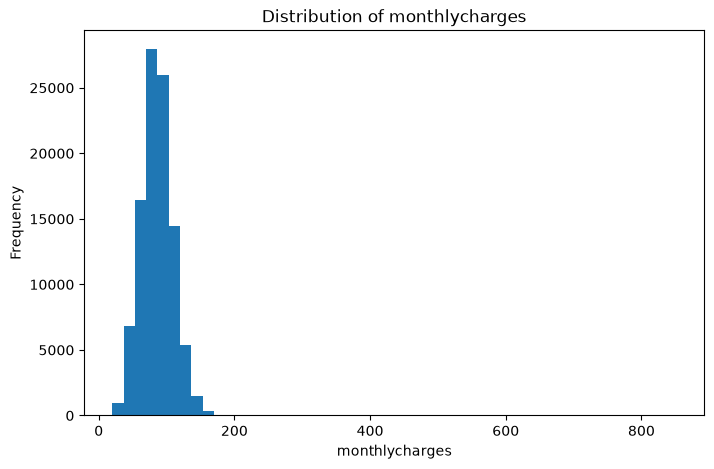

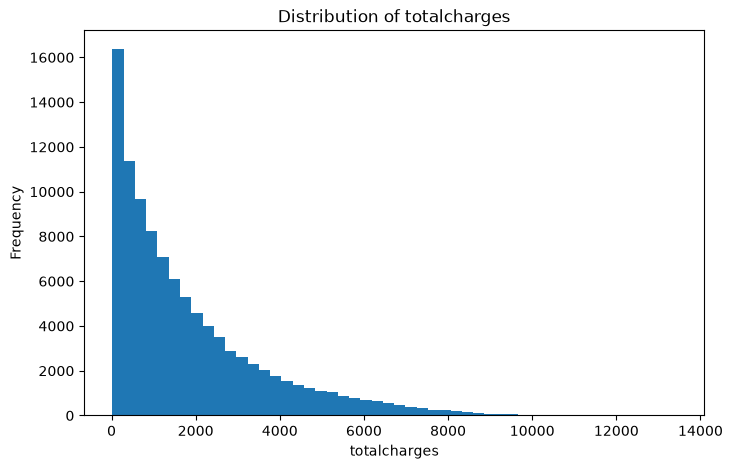

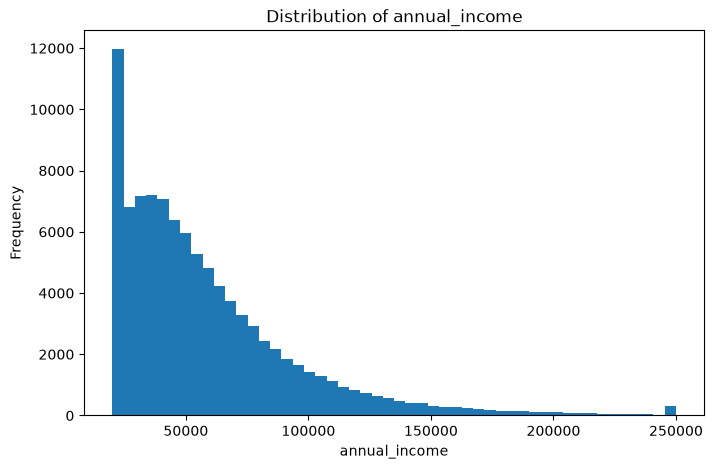

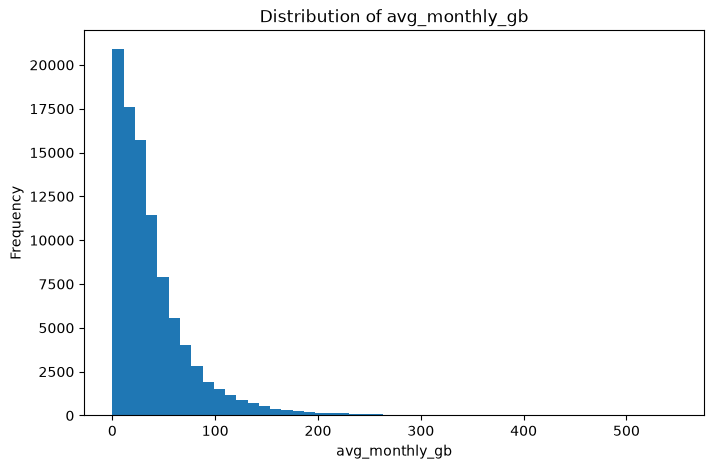

In [22]:
import matplotlib.pyplot as plt

sample = df.sample(100000, random_state=42)

columns = [
    "monthlycharges",
    "totalcharges",
    "annual_income",
    "avg_monthly_gb"
]

for col in columns:
    plt.figure(figsize=(8, 5))
    plt.hist(sample[col].dropna(), bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [23]:
binary_cols = [
    "senior_citizen",
    "has_phone_service",
    "has_internet_service",
    "has_online_security",
    "has_online_backup",
    "has_device_protection",
    "has_tech_support",
    "has_streaming_tv",
    "has_streaming_movies",
    "churn"
]

for col in binary_cols:
    print(col, df[col].unique())

senior_citizen [0 1]
has_phone_service [1 0]
has_internet_service [1 0]
has_online_security [0 1]
has_online_backup [0 1]
has_device_protection [1 0]
has_tech_support [1 0]
has_streaming_tv [1 0]
has_streaming_movies [1 0]
churn [0 1]


In [24]:
# Churn rate by Contract

contract_churn = df.groupby("contract")["churn"].mean() * 100

contract_churn.sort_values(ascending=False)

contract
month_to_month    26.505602
one_year          12.653052
two_year           5.651860
Name: churn, dtype: float64

In [25]:
df.groupby("contract")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("churn_rate", ascending=False)

,customers,churn_rate
contract,,
month_to_month,19992,26.505602
one_year,550468,12.653052
two_year,429540,5.651860


In [26]:
# Payment method vs churn

payment_churn = df.groupby("payment_method")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("churn_rate", ascending=False)

payment_churn

,customers,churn_rate
payment_method,,
electronic_check,250346,9.947832
bank_transfer,249910,9.943580
credit_card,349706,9.908609
mailed_check,150038,9.878831


In [27]:
# Education level vs churn

education_churn = df.groupby("education")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("churn_rate", ascending=False)

education_churn

,customers,churn_rate
education,,
master,150468,9.998139
bachelor,300324,9.950920
high_school,249348,9.912251
phd,50250,9.908458
college,249610,9.856576


In [28]:
# Marital status vs churn

marital_churn = df.groupby("marital_status")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("churn_rate", ascending=False)

marital_churn

,customers,churn_rate
marital_status,,
divorced,148976,9.980131
married,450115,9.962343
single,350830,9.879714
widowed,50079,9.696679


In [29]:
# Gender vs churn

gender_churn = df.groupby("gender")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("churn_rate", ascending=False)

gender_churn

,customers,churn_rate
gender,,
Male,490166,9.927861
Female,489595,9.921670
Other,20239,9.822620


In [30]:
# Paperless billing vs churn

paperless_churn = df.groupby("paperless_billing")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("churn_rate", ascending=False)

paperless_churn

,customers,churn_rate
paperless_billing,,
No,250120,9.990804
Yes,749880,9.899984


In [31]:
# Customer satisfaction vs churn

satisfaction_churn = df.groupby("customer_satisfaction")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

satisfaction_churn

,customers,churn_rate
customer_satisfaction,,
1.0,39270,16.722689
2.0,49262,15.849945
3.0,68647,14.529404
4.0,88057,10.853197
5.0,107603,10.248785
6.0,127536,9.482813
7.0,146692,8.617375
8.0,166732,8.195787
9.0,186280,7.482285


In [32]:
# Number of complaints vs churn

complaints_churn = df.groupby("num_complaints")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

complaints_churn

,customers,churn_rate
num_complaints,,
0.0,481239,8.095977
1.0,336819,10.463186
2.0,118816,13.403919
3.0,27537,17.688928
4.0,4907,21.418382
5.0,675,25.629630
6.0,89,33.707865
7.0,12,33.333333


In [33]:
# Number of service calls vs churn

service_calls_churn = df.groupby("num_service_calls")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

service_calls_churn

,customers,churn_rate
num_service_calls,,
0,204894,7.709352
1,297131,8.752368
2,236336,9.954895
3,140000,11.348571
4,70295,12.870048
5,30885,15.033188
6,12650,19.675889
7,4990,22.284569
8,1823,24.574877


In [34]:
# Late payments vs churn

late_payment_churn = df.groupby("late_payments")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

late_payment_churn

,customers,churn_rate
late_payments,,
0,669835,9.057454
1,268102,11.128227
2,54149,13.599512
3,7146,16.652673
4,709,21.720733
5,59,23.728814


In [35]:
# Tenure vs churn

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=[
        "1-12 months",
        "13-24 months",
        "25-36 months",
        "37-48 months",
        "49-60 months",
        "61-72 months"
    ]
)

tenure_churn = df.groupby("tenure_group", observed=True)["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

tenure_churn

,customers,churn_rate
tenure_group,,
1-12 months,418055,10.258459
13-24 months,228860,9.988639
25-36 months,139525,9.795377
37-48 months,83532,9.373653
49-60 months,51213,9.194931
61-72 months,78815,9.230476


In [36]:
# Age vs churn

age_churn = df.groupby("age")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

age_churn

,customers,churn_rate
age,,
18,41393,9.926799
19,6351,10.502283
20,6916,10.526316
21,7755,9.645390
22,8574,9.703756
...,...,...
86,576,9.375000
87,521,8.637236
88,368,7.608696


In [37]:
# Internet service vs churn

internet_churn = df.groupby("has_internet_service")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

internet_churn

,customers,churn_rate
has_internet_service,,
0,150258,11.007733
1,849742,9.730836


In [38]:
# Online security vs churn


security_churn = df.groupby("has_online_security")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

security_churn

,customers,churn_rate
has_online_security,,
0,660532,10.653685
1,339468,8.500359


In [39]:
# Online backup vs churn

backup_churn = df.groupby("has_online_backup")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("churn_rate", ascending=False)

backup_churn

,customers,churn_rate
has_online_backup,,
0,574277,10.049332
1,425723,9.751881


In [40]:
# has_device_protection vs churn

device_churn = df.groupby("has_device_protection")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("churn_rate", ascending=False)

device_churn

,customers,churn_rate
has_device_protection,,
0,702918,10.018096
1,297082,9.696986


In [41]:
#   has_tech_support vs churn

tech_support_churn = df.groupby("has_tech_support")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("churn_rate", ascending=False)

tech_support_churn

,customers,churn_rate
has_tech_support,,
0,502656,11.275107
1,497344,8.555849


In [42]:
# has_streaming_tv vs churn

streaming_tv_churn = df.groupby("has_streaming_tv")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("churn_rate", ascending=False)

streaming_tv_churn

,customers,churn_rate
has_streaming_tv,,
1,599990,9.939666
0,400010,9.897253


In [43]:
# has_streaming_movies vs churn

streaming_movies_churn = df.groupby("has_streaming_movies")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("churn_rate", ascending=False)

streaming_movies_churn

,customers,churn_rate
has_streaming_movies,,
1,549086,9.974576
0,450914,9.859530


In [44]:
# has_phone_service vs curn

phone_churn = df.groupby("has_phone_service")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("churn_rate", ascending=False)

phone_churn

,customers,churn_rate
has_phone_service,,
0,230449,10.046908
1,769551,9.885505


In [45]:
# monthlycharges vs churn

monthly_charges_churn = df.groupby(
    pd.qcut(df["monthlycharges"], 10))["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

monthly_charges_churn

,customers,churn_rate
monthlycharges,,
"(19.999, 56.57]",100018,11.075006
"(56.57, 66.65]",100043,10.076667
"(66.65, 73.86]",100004,9.848606
"(73.86, 79.89]",100051,9.679064
"(79.89, 85.48]",99995,10.337517
"(85.48, 91.08]",99916,10.157532
"(91.08, 97.21]",100017,10.066289
"(97.21, 104.63]",99992,9.847788
"(104.63, 115.54]",100000,9.401000


In [46]:
# totalcharges

total_charges_churn = df.groupby(
    pd.qcut(df["totalcharges"], 10))["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

total_charges_churn

,customers,churn_rate
totalcharges,,
"(16.299, 153.37]",100006,10.542367
"(153.37, 366.04]",99997,10.502315
"(366.04, 611.23]",99998,10.276206
"(611.23, 900.97]",100002,10.173797
"(900.97, 1249.75]",99998,10.020200
"(1249.75, 1682.28]",100003,9.974701
"(1682.28, 2252.116]",99996,9.871395
"(2252.116, 3071.412]",100000,9.644000
"(3071.412, 4447.92]",100001,9.319907


In [47]:
# annual_income

income_churn = df.groupby(
    pd.qcut(df["annual_income"], 10))["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

income_churn

,customers,churn_rate
annual_income,,
"(19999.999, 22755.78]",97005,9.891243
"(22755.78, 29625.82]",97004,10.004742
"(29625.82, 35758.8]",97004,9.872789
"(35758.8, 42032.63]",97005,10.011855
"(42032.63, 48954.6]",97003,9.841964
"(48954.6, 56996.47]",97004,9.841862
"(56996.47, 67128.17]",97004,10.095460
"(67128.17, 81206.39]",97004,9.816090
"(81206.39, 105803.5]",97004,9.814028


In [48]:
# avg_monthly_gb

gb_churn = df.groupby(
    pd.qcut(
        df["avg_monthly_gb"],
        10,
        duplicates="drop"
    )
)["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

gb_churn

,customers,churn_rate
avg_monthly_gb,,
"(-0.001, 9.48]",190081,10.691232
"(9.48, 15.78]",94989,9.725337
"(15.78, 21.51]",94932,9.818607
"(21.51, 27.77]",95035,9.586994
"(27.77, 35.2]",95029,9.703354
"(35.2, 44.91]",94926,9.768662
"(44.91, 59.15]",95000,9.970526
"(59.15, 86.0]",94998,9.533885
"(86.0, 557.824]",94998,9.629676


In [49]:
# credit_score

credit_churn = df.groupby(
    pd.qcut(df["credit_score"], 10)
)["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

credit_churn

,customers,churn_rate
credit_score,,
"(299.999, 564.0]",96008,9.931464
"(564.0, 604.0]",97574,9.923750
"(604.0, 632.0]",94622,9.997675
"(632.0, 657.0]",98460,9.876092
"(657.0, 680.0]",97251,9.985501
"(680.0, 702.0]",92543,9.775996
"(702.0, 727.0]",98291,9.879847
"(727.0, 755.0]",93770,10.092780
"(755.0, 795.0]",96315,9.864507


In [50]:
# days_since_last_interaction

interaction_churn = df.groupby(
    pd.qcut(df["days_since_last_interaction"], 10)
)["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
)

interaction_churn

,customers,churn_rate
days_since_last_interaction,,
"(0.999, 4.0]",105408,9.894885
"(4.0, 10.0]",112218,10.055428
"(10.0, 15.0]",82567,9.827171
"(15.0, 22.0]",100467,9.892801
"(22.0, 31.0]",108485,9.856662
"(31.0, 41.0]",98024,9.934302
"(41.0, 54.0]",99014,10.030905
"(54.0, 72.0]",96831,9.934835
"(72.0, 103.0]",97708,9.919352


In [51]:
services_churn = df.groupby("num_services")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("num_services")

services_churn

,customers,churn_rate
num_services,,
1,286888,11.035317
2,256335,10.320089
3,214261,9.592506
4,133531,8.875842
5,66654,8.388094
6,42331,7.365760


In [52]:
dependents_churn = df.groupby("dependents")["churn"].agg(
    customers="count",
    churn_rate="mean"
).assign(
    churn_rate=lambda x: x["churn_rate"] * 100
).sort_values("dependents")

dependents_churn

,customers,churn_rate
dependents,,
0,449368,9.922825
1,359443,9.940102
2,143783,9.883644
3,38247,9.864826
4,7714,9.904071
5,1445,11.072664


In [53]:
numeric_cols = df.select_dtypes(include="number").columns

corr_matrix = df[numeric_cols].corr()

corr_matrix["churn"].sort_values(ascending=False)

churn                          1.000000
num_complaints                 0.079985
num_service_calls              0.077284
late_payments                  0.047705
has_streaming_movies           0.001915
has_streaming_tv               0.000695
annual_income                  0.000466
days_since_last_interaction    0.000391
senior_citizen                 0.000344
age                            0.000264
dependents                    -0.000145
credit_score                  -0.000378
has_phone_service             -0.002274
has_device_protection         -0.004908
has_online_backup             -0.004919
avg_monthly_gb                -0.006144
tenure                        -0.012709
monthlycharges                -0.013849
has_internet_service          -0.015261
totalcharges                  -0.016501
num_services                  -0.033378
has_online_security           -0.034106
has_tech_support              -0.045477
customer_satisfaction         -0.084749
Name: churn, dtype: float64

Feature-to-feature correlation

In [54]:
corr_matrix = df[numeric_cols].corr()

corr_matrix

,age,annual_income,dependents,tenure,senior_citizen,monthlycharges,totalcharges,num_services,has_phone_service,has_internet_service,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
age,1.000000,0.000807,-0.000254,0.001752,0.000435,-0.000574,0.001432,-0.000587,0.002293,0.000440,...,0.000987,0.000910,-0.001211,-0.000886,-0.001008,0.001538,-0.000139,0.000453,-0.000664,0.000264
annual_income,0.000807,1.000000,-0.000711,-0.000732,0.000878,0.001081,-0.000286,0.001629,0.002375,-0.000347,...,0.001088,-0.000775,0.001414,0.001505,0.000759,0.000003,-0.001068,0.000783,-0.000970,0.000466
dependents,-0.000254,-0.000711,1.000000,-0.001216,-0.000459,-0.002295,-0.001135,-0.000736,0.001117,0.000846,...,0.000780,0.001237,-0.002433,0.001686,-0.000727,0.002454,0.001243,0.001398,0.000143,-0.000145
tenure,0.001752,-0.000732,-0.001216,1.000000,-0.001340,-0.000631,0.912829,-0.001431,0.001282,-0.000082,...,-0.002728,-0.000473,-0.000633,-0.002449,-0.000716,-0.001073,-0.000866,0.000092,0.002538,-0.012709
senior_citizen,0.000435,0.000878,-0.000459,-0.001340,1.000000,-0.000347,-0.000820,-0.000488,-0.000023,-0.000384,...,0.001728,-0.001200,-0.000774,-0.000619,-0.000422,-0.000963,0.000195,0.001256,0.000466,0.000344
monthlycharges,-0.000574,0.001081,-0.002295,-0.000631,-0.000347,1.000000,0.224526,0.410663,0.066989,0.386898,...,-0.000863,0.001641,-0.000731,0.001802,0.000788,-0.000119,0.143499,-0.002576,-0.001425,-0.013849
totalcharges,0.001432,-0.000286,-0.001135,0.912829,-0.000820,0.224526,1.000000,0.132443,0.022820,0.126599,...,-0.002767,0.000198,-0.001421,-0.002005,-0.000401,-0.000897,0.045982,-0.000493,0.002439,-0.016501
num_services,-0.000587,0.001629,-0.000736,-0.001431,-0.000488,0.410663,0.132443,1.000000,-0.000568,0.000263,...,-0.001623,0.000626,0.000308,0.000917,0.001962,-0.000155,-0.000370,-0.001065,-0.000397,-0.033378
has_phone_service,0.002293,0.002375,0.001117,0.001282,-0.000023,0.066989,0.022820,-0.000568,1.000000,0.171257,...,0.003907,-0.000223,0.000231,-0.000071,-0.000629,0.000048,0.063088,0.000632,-0.000312,-0.002274
has_internet_service,0.000440,-0.000347,0.000846,-0.000082,-0.000384,0.386898,0.126599,0.000263,0.171257,1.000000,...,-0.001524,-0.000070,0.001202,0.001904,0.000434,-0.000567,0.371405,-0.001493,-0.000191,-0.015261


In [55]:
df.columns.tolist()

['customer_id',
 'signup_date',
 'age',
 'gender',
 'annual_income',
 'education',
 'marital_status',
 'dependents',
 'tenure',
 'contract',
 'payment_method',
 'paperless_billing',
 'senior_citizen',
 'monthlycharges',
 'totalcharges',
 'num_services',
 'has_phone_service',
 'has_internet_service',
 'has_online_security',
 'has_online_backup',
 'has_device_protection',
 'has_tech_support',
 'has_streaming_tv',
 'has_streaming_movies',
 'customer_satisfaction',
 'num_complaints',
 'num_service_calls',
 'late_payments',
 'avg_monthly_gb',
 'days_since_last_interaction',
 'credit_score',
 'churn',
 'tenure_group']

Data Cleaning

In [56]:
df = df.drop(columns=["customer_id", "tenure_group"])

In [57]:
df.shape

(1000000, 31)

In [58]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

avg_monthly_gb           50012
credit_score             40395
annual_income            29959
num_complaints           29906
customer_satisfaction    19921
dtype: int64

In [59]:
missing_cols = [
    "avg_monthly_gb",
    "credit_score",
    "annual_income",
    "num_complaints",
    "customer_satisfaction"
]

df[missing_cols].agg(["mean", "median"])

,avg_monthly_gb,credit_score,annual_income,num_complaints,customer_satisfaction
mean,39.095179,678.562134,58788.311936,0.701667,6.15911
median,27.770000,680.000000,48954.600000,1.000000,7.00000


In [60]:
for col in missing_cols:
    print(f"\n{col}")
    print(
        df.groupby(df[col].isna())["churn"]
        .agg(customers="count", churn_rate="mean")
        .assign(churn_rate=lambda x: x["churn_rate"] * 100)
    )


avg_monthly_gb
                customers  churn_rate
avg_monthly_gb                       
False              949988     9.91202
True                50012    10.12557

credit_score
              customers  churn_rate
credit_score                       
False            959605    9.921270
True              40395    9.956678

annual_income
               customers  churn_rate
annual_income                       
False             970041    9.923189
True               29959    9.906873

num_complaints
                customers  churn_rate
num_complaints                       
False              970094    9.922544
True                29906    9.927774

customer_satisfaction
                       customers  churn_rate
customer_satisfaction                       
False                     980079    9.924914
True                       19921    9.813764


In [61]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


signup_date


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9432\3880335109.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


signup_date
2022-12-12 12:53:58.199463    1
2022-01-13 12:53:58.199973    1
2023-09-04 12:53:58.199985    1
2022-06-27 12:53:58.199992    1
2022-12-08 12:53:58.199999    1
                             ..
2025-02-03 12:54:09.482412    1
2024-09-08 12:54:09.482417    1
2021-09-13 12:54:09.482423    1
2025-08-30 12:54:09.482428    1
2023-02-14 12:54:09.482434    1
Name: count, Length: 1000000, dtype: int64

gender
gender
Male      490166
Female    489595
Other      20239
Name: count, dtype: int64

education
education
bachelor       300324
college        249610
high_school    249348
master         150468
phd             50250
Name: count, dtype: int64

marital_status
marital_status
married     450115
single      350830
divorced    148976
widowed      50079
Name: count, dtype: int64

contract
contract
one_year          550468
two_year          429540
month_to_month     19992
Name: count, dtype: int64

payment_method
payment_method
credit_card         349706
electronic_check    250346
bank_t

In [62]:
categorical_cols = df.select_dtypes(include="str").columns

for col in categorical_cols:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].unique()[:20])


signup_date
Unique values: 1000000
<StringArray>
['2022-12-12 12:53:58.199463', '2022-01-13 12:53:58.199973',
 '2023-09-04 12:53:58.199985', '2022-06-27 12:53:58.199992',
 '2022-12-08 12:53:58.199999', '2023-01-12 12:53:58.200006',
 '2021-04-23 12:53:58.200012', '2023-03-04 12:53:58.200018',
 '2021-07-18 12:53:58.200023', '2025-09-12 12:53:58.200029',
 '2024-10-02 12:53:58.200035', '2022-08-22 12:53:58.200041',
 '2025-02-15 12:53:58.200047', '2021-12-21 12:53:58.200053',
 '2025-10-16 12:53:58.200058', '2022-03-17 12:53:58.200064',
 '2022-12-15 12:53:58.200070', '2023-08-24 12:53:58.200076',
 '2021-05-30 12:53:58.200082', '2025-09-03 12:53:58.200087']
Length: 20, dtype: str

gender
Unique values: 3
<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

education
Unique values: 5
<StringArray>
['college', 'master', 'high_school', 'bachelor', 'phd']
Length: 5, dtype: str

marital_status
Unique values: 4
<StringArray>
['married', 'widowed', 'single', 'divorced']
Length: 4, dtype

In [63]:
# Convert signup_date

df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")

df["signup_date"].dtype

dtype('<M8[us]')

In [64]:
df["signup_date"].isna().sum()

np.int64(0)

In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,44.724603,14.479468,18.0,34.00,44.00,55.00,90.000000
annual_income,970041.0,58788.311936,37137.433079,20000.0,32712.56,48954.60,73475.13,250000.000000
dependents,1000000.0,0.799831,0.893654,0.0,0.00,1.00,1.00,5.000000
tenure,1000000.0,22.381923,20.073341,1.0,6.00,16.00,33.00,72.000000
senior_citizen,1000000.0,0.199511,0.399633,0.0,0.00,0.00,0.00,1.000000
monthlycharges,1000000.0,86.443701,27.592430,20.0,70.49,85.48,100.68,854.956730
totalcharges,1000000.0,1837.321438,1803.721634,16.3,484.53,1249.75,2617.66,16252.861508
num_services,1000000.0,2.563721,1.412330,1.0,1.00,2.00,3.00,6.000000
has_phone_service,1000000.0,0.769551,0.421120,0.0,1.00,1.00,1.00,1.000000
has_internet_service,1000000.0,0.849742,0.357324,0.0,1.00,1.00,1.00,1.000000


In [67]:
binary_cols = [
    "senior_citizen",
    "has_phone_service",
    "has_internet_service",
    "has_online_security",
    "has_online_backup",
    "has_device_protection",
    "has_tech_support",
    "has_streaming_tv",
    "has_streaming_movies"
]

for col in binary_cols:
    print(col, df[col].unique())

senior_citizen [0 1]
has_phone_service [1 0]
has_internet_service [1 0]
has_online_security [0 1]
has_online_backup [0 1]
has_device_protection [1 0]
has_tech_support [1 0]
has_streaming_tv [1 0]
has_streaming_movies [1 0]


In [68]:
df["churn"].value_counts(dropna=False)

churn
0    900773
1     99227
Name: count, dtype: int64

In [69]:
(df[numeric_cols] < 0).sum().sort_values(ascending=False)

age                            0
annual_income                  0
dependents                     0
tenure                         0
senior_citizen                 0
monthlycharges                 0
totalcharges                   0
num_services                   0
has_phone_service              0
has_internet_service           0
has_online_security            0
has_online_backup              0
has_device_protection          0
has_tech_support               0
has_streaming_tv               0
has_streaming_movies           0
customer_satisfaction          0
num_complaints                 0
num_service_calls              0
late_payments                  0
avg_monthly_gb                 0
days_since_last_interaction    0
credit_score                   0
churn                          0
dtype: int64

In [70]:
df.to_csv(r"C:\Users\LENOVO\Desktop\customer-churn-prediction\data\customer_churn_cleaned.csv", index=False)